# 65 - SigLIP 2 JS トークナイザー＋日本語テキスト評価

## 概要
SigLIP 2 の **最も重要な実験**: Gemma BPE トークナイザーにより、
SigLIP 1 の JS での日本語 `<unk>` 問題が解決されたかを検証する。

## 背景（SigLIP 1 の問題）
- SigLIP 1: Unigram トークナイザー（32K語彙）で `byte_fallback` 未実装
- Python: SentencePiece C++ で byte_fallback 動作 → "公園" → `<0xE5><0x85><0xAC>...`
- JS: Transformers.js の Unigram で byte_fallback 未実装 → "公園" → `<unk>`
- 結果: 英語 MRR 0.883、**日本語 MRR 0.273**（壊滅的）

## SigLIP 2 の期待
- Gemma BPE トークナイザー（256K語彙）
- BPE は Transformers.js で byte_fallback が実装済み
- → 日本語テキスト埋め込みが Python と一致するはず

## 評価項目
1. **トークナイザー比較**: Python vs JS のトークン列出力
2. **テキスト埋め込み比較**: コサイン類似度（EN + JA）
3. **テキスト→画像検索 MRR**: 18クエリでの評価

In [1]:
import json
import os
import subprocess
import tempfile
from datetime import datetime
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine as cosine_distance

from image_vector_poc import SigLIP2Embedder

## 1. 環境設定

In [2]:
# nvm の Node.js パスを追加
NVM_NODE_BIN = Path.home() / ".nvm/versions/node/v24.13.1/bin"
os.environ["PATH"] = str(NVM_NODE_BIN) + ":" + os.environ.get("PATH", "")

result = subprocess.run(["node", "--version"], capture_output=True, text=True)
print(f"Node.js version: {result.stdout.strip()}")

DB_PATH = Path("../data/images.duckdb")
JS_DIR = Path("../js")
PYTHON_MODEL = "google/siglip2-base-patch16-224"

Node.js version: v24.13.1


## 2. Python トークナイザーの分析

In [3]:
from transformers import AutoTokenizer

py_tokenizer = AutoTokenizer.from_pretrained(PYTHON_MODEL)

print(f"Tokenizer class: {py_tokenizer.__class__.__name__}")
print(f"Vocab size: {py_tokenizer.vocab_size}")
print(f"Model max length: {py_tokenizer.model_max_length}")

# テスト文
test_texts = [
    # 英語
    "a park with trees and nature",
    "night cityscape Tokyo",
    "Python conference presentation",
    # 日本語（重要！）
    "公園の自然風景",
    "東京の夜景",
    "カンファレンスの講演",
    "人物の写真",
    "緑の木々",
    "夜の街",
]

print("\n" + "=" * 80)
print("Python Tokenizer Output")
print("=" * 80)

py_token_results = []
for text in test_texts:
    tokens = py_tokenizer.tokenize(text)
    input_ids = py_tokenizer.encode(text)
    
    has_unk = any(t == '<unk>' for t in tokens)
    
    py_token_results.append({
        'text': text,
        'tokens': tokens,
        'token_count': len(tokens),
        'input_ids': input_ids,
        'has_unk': has_unk,
    })
    
    unk_marker = " *** HAS <unk> ***" if has_unk else ""
    print(f"\n  Text: {text}")
    print(f"  Tokens ({len(tokens)}): {tokens[:20]}{'...' if len(tokens) > 20 else ''}{unk_marker}")
    print(f"  IDs: {input_ids[:20]}{'...' if len(input_ids) > 20 else ''}")

Tokenizer class: TokenizersBackend
Vocab size: 256000
Model max length: 1000000000000000019884624838656

Python Tokenizer Output

  Text: a park with trees and nature
  Tokens (6): ['a', '▁park', '▁with', '▁trees', '▁and', '▁nature']
  IDs: [235250, 7441, 675, 8195, 578, 4460, 1]

  Text: night cityscape Tokyo
  Tokens (3): ['night', '▁cityscape', '▁Tokyo']
  IDs: [6735, 172824, 22099, 1]

  Text: Python conference presentation
  Tokens (3): ['Python', '▁conference', '▁presentation']
  IDs: [27922, 11982, 14446, 1]

  Text: 公園の自然風景
  Tokens (4): ['公園', 'の', '自然', '風景']
  IDs: [44978, 235372, 17689, 91712, 1]

  Text: 東京の夜景
  Tokens (3): ['東京', 'の', '夜景']
  IDs: [19485, 235372, 201249, 1]

  Text: カンファレンスの講演
  Tokens (5): ['カン', 'ファ', 'レン', 'スの', '講演']
  IDs: [53788, 13449, 16402, 59333, 158318, 1]

  Text: 人物の写真
  Tokens (2): ['人物', 'の写真']
  IDs: [31649, 84500, 1]

  Text: 緑の木々
  Tokens (3): ['緑', 'の木', '々']
  IDs: [238619, 138722, 236461, 1]

  Text: 夜の街
  Tokens (2): ['夜の', '街']
  ID

## 3. JS トークナイザーの分析

Node.js スクリプトを使って JS 側のトークン化結果を取得する。

In [4]:
# JS でトークナイザーのみテストするインラインスクリプト
js_tokenizer_script = """
import { AutoTokenizer } from '@huggingface/transformers';

const MODEL_NAME = 'onnx-community/siglip2-base-patch16-224-ONNX';
const texts = JSON.parse(process.argv[2]);

async function main() {
    const tokenizer = await AutoTokenizer.from_pretrained(MODEL_NAME);
    console.error(`Tokenizer class: ${tokenizer.constructor.name}`);
    
    const results = [];
    for (const text of texts) {
        const encoded = tokenizer(text, { padding: false, truncation: false });
        const input_ids = Array.from(encoded.input_ids.data).map(Number);
        
        // Decode each token
        const tokens = [];
        for (const id of input_ids) {
            const decoded = tokenizer.decode([id], { skip_special_tokens: false });
            tokens.push(decoded);
        }
        
        // Check for <unk> token (id=3 for Gemma tokenizer)
        const unk_id = 3;
        const has_unk = input_ids.includes(unk_id);
        
        results.push({
            text,
            tokens,
            token_count: tokens.length,
            input_ids,
            has_unk,
        });
    }
    
    // Output as JSON to stdout
    console.log(JSON.stringify(results));
}

main().catch(err => { console.error(err); process.exit(1); });
"""

# スクリプトを js/ ディレクトリ内に書き出し（node_modules が解決されるように）
script_path = JS_DIR / "_tmp_tokenizer_test.mjs"
script_path.write_text(js_tokenizer_script)

# 実行
texts_json = json.dumps(test_texts, ensure_ascii=False)
result = subprocess.run(
    ["node", str(script_path), texts_json],
    capture_output=True, text=True, cwd=str(JS_DIR)
)

print("JS stderr:")
print(result.stderr)

# クリーンアップ
script_path.unlink(missing_ok=True)

if result.returncode != 0:
    print(f"ERROR: JS process failed with return code {result.returncode}")
    js_token_results = []  # empty fallback to prevent NameError
else:
    js_token_results = json.loads(result.stdout)
    
    print("\n" + "=" * 80)
    print("JS Tokenizer Output")
    print("=" * 80)
    
    for r in js_token_results:
        unk_marker = " *** HAS <unk> ***" if r['has_unk'] else ""
        print(f"\n  Text: {r['text']}")
        print(f"  Tokens ({r['token_count']}): {r['tokens'][:20]}{'...' if r['token_count'] > 20 else ''}{unk_marker}")
        print(f"  IDs: {r['input_ids'][:20]}{'...' if len(r['input_ids']) > 20 else ''}")

JS stderr:
Tokenizer class: GemmaTokenizer


JS Tokenizer Output

  Text: a park with trees and nature
  Tokens (7): ['a', ' park', ' with', ' trees', ' and', ' nature', '<eos>']
  IDs: [235250, 7441, 675, 8195, 578, 4460, 1]

  Text: night cityscape Tokyo
  Tokens (4): ['night', ' cityscape', ' Tokyo', '<eos>']
  IDs: [6735, 172824, 22099, 1]

  Text: Python conference presentation
  Tokens (4): ['Python', ' conference', ' presentation', '<eos>']
  IDs: [27922, 11982, 14446, 1]

  Text: 公園の自然風景
  Tokens (5): ['公園', 'の', '自然', '風景', '<eos>']
  IDs: [44978, 235372, 17689, 91712, 1]

  Text: 東京の夜景
  Tokens (4): ['東京', 'の', '夜景', '<eos>']
  IDs: [19485, 235372, 201249, 1]

  Text: カンファレンスの講演
  Tokens (6): ['カン', 'ファ', 'レン', 'スの', '講演', '<eos>']
  IDs: [53788, 13449, 16402, 59333, 158318, 1]

  Text: 人物の写真
  Tokens (3): ['人物', 'の写真', '<eos>']
  IDs: [31649, 84500, 1]

  Text: 緑の木々
  Tokens (4): ['緑', 'の木', '々', '<eos>']
  IDs: [238619, 138722, 236461, 1]

  Text: 夜の街
  Tokens (3): ['夜の', '

## 4. Python vs JS トークナイザー比較

In [5]:
print("=" * 80)
print("Python vs JS トークナイザー比較")
print("=" * 80)

comparison_data = []

for py_r, js_r in zip(py_token_results, js_token_results):
    text = py_r['text']
    is_japanese = any(ord(c) > 0x3000 for c in text)
    
    # Input IDs の一致度
    py_ids = py_r['input_ids']
    js_ids = js_r['input_ids']
    ids_match = py_ids == js_ids
    
    # Jaccard 類似度
    py_set = set(py_ids)
    js_set = set(js_ids)
    jaccard = len(py_set & js_set) / len(py_set | js_set) if py_set | js_set else 1.0
    
    lang = "JA" if is_japanese else "EN"
    py_unk = "YES" if py_r['has_unk'] else "no"
    js_unk = "YES" if js_r['has_unk'] else "no"
    match_str = "EXACT" if ids_match else f"Jaccard={jaccard:.3f}"
    
    comparison_data.append({
        'text': text, 'lang': lang,
        'py_tokens': py_r['token_count'], 'js_tokens': js_r['token_count'],
        'py_unk': py_r['has_unk'], 'js_unk': js_r['has_unk'],
        'ids_match': ids_match, 'jaccard': jaccard,
    })
    
    print(f"\n  [{lang}] {text}")
    print(f"    Python: {py_r['token_count']} tokens, <unk>={py_unk}")
    print(f"    JS:     {js_r['token_count']} tokens, <unk>={js_unk}")
    print(f"    Match:  {match_str}")

# サマリー
comp_df = pd.DataFrame(comparison_data)
print("\n" + "=" * 60)
print("サマリー")
print("=" * 60)

en_data = comp_df[comp_df['lang'] == 'EN']
ja_data = comp_df[comp_df['lang'] == 'JA']

print(f"\n英語:")
print(f"  完全一致: {en_data['ids_match'].sum()}/{len(en_data)}")
print(f"  <unk> あり (Python): {en_data['py_unk'].sum()}/{len(en_data)}")
print(f"  <unk> あり (JS):     {en_data['js_unk'].sum()}/{len(en_data)}")

print(f"\n日本語:")
print(f"  完全一致: {ja_data['ids_match'].sum()}/{len(ja_data)}")
print(f"  <unk> あり (Python): {ja_data['py_unk'].sum()}/{len(ja_data)}")
print(f"  <unk> あり (JS):     {ja_data['js_unk'].sum()}/{len(ja_data)}")

# SigLIP 1 との比較
print(f"\n--- SigLIP 1 との比較 ---")
print(f"SigLIP 1 JS: 英語 OK, 日本語 → <unk>（全滅）")
print(f"SigLIP 2 JS: 上記の結果を確認")

Python vs JS トークナイザー比較

  [EN] a park with trees and nature
    Python: 6 tokens, <unk>=no
    JS:     7 tokens, <unk>=no
    Match:  EXACT

  [EN] night cityscape Tokyo
    Python: 3 tokens, <unk>=no
    JS:     4 tokens, <unk>=no
    Match:  EXACT

  [EN] Python conference presentation
    Python: 3 tokens, <unk>=no
    JS:     4 tokens, <unk>=no
    Match:  EXACT

  [JA] 公園の自然風景
    Python: 4 tokens, <unk>=no
    JS:     5 tokens, <unk>=no
    Match:  EXACT

  [JA] 東京の夜景
    Python: 3 tokens, <unk>=no
    JS:     4 tokens, <unk>=no
    Match:  EXACT

  [JA] カンファレンスの講演
    Python: 5 tokens, <unk>=no
    JS:     6 tokens, <unk>=no
    Match:  EXACT

  [JA] 人物の写真
    Python: 2 tokens, <unk>=no
    JS:     3 tokens, <unk>=no
    Match:  EXACT

  [JA] 緑の木々
    Python: 3 tokens, <unk>=no
    JS:     4 tokens, <unk>=no
    Match:  EXACT

  [JA] 夜の街
    Python: 2 tokens, <unk>=no
    JS:     3 tokens, <unk>=no
    Match:  EXACT

サマリー

英語:
  完全一致: 3/3
  <unk> あり (Python): 0/3
  <unk> あり (JS)

## 5. テキスト埋め込みの比較（Python vs JS）

In [6]:
# Python 側のテキスト埋め込み
embedder = SigLIP2Embedder(model_name=PYTHON_MODEL, device="cuda")
print(f"Model loaded: {embedder.model_name}")

# 18 クエリのテキスト
all_texts = [q['query'] for q in [
    {"query": "a park with trees and nature"},
    {"query": "village park with greenery"},
    {"query": "night cityscape Tokyo"},
    {"query": "city lights at night"},
    {"query": "Python conference presentation"},
    {"query": "conference hall with audience"},
    {"query": "speaker giving a talk"},
    {"query": "portrait photo of a person"},
    {"query": "outdoor nature scene"},
    {"query": "urban night photography"},
    {"query": "tech conference event"},
    {"query": "people at an event"},
    {"query": "公園の自然風景"},
    {"query": "東京の夜景"},
    {"query": "カンファレンスの講演"},
    {"query": "人物の写真"},
    {"query": "緑の木々"},
    {"query": "夜の街"},
]]

# Python 埋め込み
py_text_embeddings = embedder.embed_texts(all_texts)
print(f"Python text embeddings shape: {py_text_embeddings.shape}")

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Model loaded: google/siglip2-base-patch16-224
Python text embeddings shape: (18, 768)


In [7]:
# JS 側のテキスト埋め込み
texts_path = Path(tempfile.mktemp(suffix=".json"))
output_path = Path(tempfile.mktemp(suffix=".json"))

with open(texts_path, "w") as f:
    json.dump(all_texts, f, ensure_ascii=False)

cmd = [
    "node", str(JS_DIR / "embed_texts_siglip2.mjs"),
    "--texts", str(texts_path),
    "--output", str(output_path),
    "--dtype", "fp32",
]

result = subprocess.run(cmd, capture_output=True, text=True, cwd=str(JS_DIR))
print("JS stderr:")
print(result.stderr)

if result.returncode != 0:
    print(f"ERROR: JS process failed")
    js_text_output = None
else:
    with open(output_path) as f:
        js_text_output = json.load(f)
    print(f"JS text embeddings: {js_text_output['count']}")

texts_path.unlink(missing_ok=True)
output_path.unlink(missing_ok=True)

JS stderr:
Model: onnx-community/siglip2-base-patch16-224-ONNX
dtype: fp32
Texts to process: 18
Loading model and tokenizer...
Model loaded in 3.2s
Tokenizer type: GemmaTokenizer
  [10/18] 0.3s elapsed
  [18/18] 0.5s elapsed
Done. 18 text embeddings saved to /tmp/tmp3l4z8q1m.json (0.5s)

JS text embeddings: 18


In [8]:
# Python vs JS テキスト埋め込みのコサイン類似度
if js_text_output:
    print("=" * 80)
    print("Python vs JS テキスト埋め込み コサイン類似度")
    print("=" * 80)
    
    text_sims = []
    for i, (text, js_item) in enumerate(zip(all_texts, js_text_output['embeddings'])):
        py_emb = py_text_embeddings[i]
        js_emb = np.array(js_item['embedding'], dtype=np.float32)
        sim = 1.0 - cosine_distance(py_emb, js_emb)
        
        is_ja = any(ord(c) > 0x3000 for c in text)
        lang = "JA" if is_ja else "EN"
        
        text_sims.append({'text': text, 'lang': lang, 'cosine_sim': sim})
        print(f"  [{lang}] {text[:40]:40s} | cos_sim = {sim:.6f}")
    
    text_sims_df = pd.DataFrame(text_sims)
    
    print("\n--- サマリー ---")
    for lang in ['EN', 'JA']:
        lang_df = text_sims_df[text_sims_df['lang'] == lang]
        print(f"{lang}: mean={lang_df['cosine_sim'].mean():.6f}, "
              f"min={lang_df['cosine_sim'].min():.6f}, max={lang_df['cosine_sim'].max():.6f}")
    
    print(f"\n--- 比較（他モデル）---")
    print(f"SigLIP 1: EN=1.000, JA=0.656 (byte_fallback 未実装のため)")
    print(f"CLIP-L:   EN=1.000, JA=1.000")
    print(f"SigLIP 2: EN={text_sims_df[text_sims_df['lang']=='EN']['cosine_sim'].mean():.6f}, "
          f"JA={text_sims_df[text_sims_df['lang']=='JA']['cosine_sim'].mean():.6f}")

Python vs JS テキスト埋め込み コサイン類似度
  [EN] a park with trees and nature             | cos_sim = 1.000000
  [EN] village park with greenery               | cos_sim = 1.000000
  [EN] night cityscape Tokyo                    | cos_sim = 1.000000
  [EN] city lights at night                     | cos_sim = 1.000000
  [EN] Python conference presentation           | cos_sim = 1.000000
  [EN] conference hall with audience            | cos_sim = 1.000000
  [EN] speaker giving a talk                    | cos_sim = 1.000000
  [EN] portrait photo of a person               | cos_sim = 1.000000
  [EN] outdoor nature scene                     | cos_sim = 1.000000
  [EN] urban night photography                  | cos_sim = 1.000000
  [EN] tech conference event                    | cos_sim = 1.000000
  [EN] people at an event                       | cos_sim = 1.000000
  [JA] 公園の自然風景                                  | cos_sim = 1.000000
  [JA] 東京の夜景                                    | cos_sim = 1.000000
  [J

## 6. テキスト→画像検索 MRR の比較

In [9]:
# Python 画像埋め込みの読み込み（DuckDB から）
conn = duckdb.connect(str(DB_PATH), read_only=True)

catalog_df = conn.execute("""
    SELECT id, file_path, category FROM image_catalog ORDER BY id
""").fetchdf()

py_emb_df = conn.execute("""
    SELECT c.id, e.embedding
    FROM image_catalog c
    JOIN image_embeddings e ON c.id = e.id
    WHERE e.model_name = ?
    ORDER BY c.id
""", [PYTHON_MODEL]).fetchdf()
conn.close()

image_embeddings = np.array(py_emb_df['embedding'].tolist(), dtype=np.float32)
norms = np.linalg.norm(image_embeddings, axis=1, keepdims=True)
image_embeddings_norm = image_embeddings / np.clip(norms, 1e-8, None)
categories = catalog_df['category'].tolist()

print(f"Image embeddings: {image_embeddings.shape}")

Image embeddings: (378, 768)


In [10]:
# テストクエリ
test_queries = [
    {"query": "a park with trees and nature", "expected_categories": ["KashiwaVillagePark2026"], "lang": "en"},
    {"query": "village park with greenery", "expected_categories": ["KashiwaVillagePark2026"], "lang": "en"},
    {"query": "night cityscape Tokyo", "expected_categories": ["TokyoNight202505"], "lang": "en"},
    {"query": "city lights at night", "expected_categories": ["TokyoNight202505"], "lang": "en"},
    {"query": "Python conference presentation", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"query": "conference hall with audience", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"query": "speaker giving a talk", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"query": "portrait photo of a person", "expected_categories": ["terada"], "lang": "en"},
    {"query": "outdoor nature scene", "expected_categories": ["KashiwaVillagePark2026"], "lang": "en"},
    {"query": "urban night photography", "expected_categories": ["TokyoNight202505"], "lang": "en"},
    {"query": "tech conference event", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"query": "people at an event", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "en"},
    {"query": "公園の自然風景", "expected_categories": ["KashiwaVillagePark2026"], "lang": "ja"},
    {"query": "東京の夜景", "expected_categories": ["TokyoNight202505"], "lang": "ja"},
    {"query": "カンファレンスの講演", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "lang": "ja"},
    {"query": "人物の写真", "expected_categories": ["terada"], "lang": "ja"},
    {"query": "緑の木々", "expected_categories": ["KashiwaVillagePark2026"], "lang": "ja"},
    {"query": "夜の街", "expected_categories": ["TokyoNight202505"], "lang": "ja"},
]


def compute_search_mrr(text_embeddings, image_embeddings_norm, categories, test_queries):
    """テキスト埋め込みを使って画像検索の MRR を計算する。"""
    results = []
    for i, q in enumerate(test_queries):
        text_emb = text_embeddings[i]
        text_emb = text_emb / np.linalg.norm(text_emb)
        
        similarities = np.dot(image_embeddings_norm, text_emb)
        top_indices = np.argsort(similarities)[::-1][:20]
        result_cats = [categories[idx] for idx in top_indices]
        is_relevant = [cat in q['expected_categories'] for cat in result_cats]
        
        mrr = 0.0
        for j, rel in enumerate(is_relevant):
            if rel:
                mrr = 1.0 / (j + 1)
                break
        
        p_at_1 = sum(is_relevant[:1])
        results.append({'query': q['query'], 'lang': q['lang'], 'MRR': mrr, 'P@1': p_at_1})
    
    return pd.DataFrame(results)

In [11]:
# Python テキスト埋め込みでの検索
py_search_df = compute_search_mrr(py_text_embeddings, image_embeddings_norm, categories, test_queries)

print("Python テキスト検索結果:")
for _, row in py_search_df.iterrows():
    print(f"  [{row['lang'].upper()}] {row['query'][:35]:35s} | MRR={row['MRR']:.2f} | P@1={row['P@1']:.0f}")

print(f"\n全体 MRR: {py_search_df['MRR'].mean():.4f}")
print(f"EN MRR:   {py_search_df[py_search_df['lang']=='en']['MRR'].mean():.4f}")
print(f"JA MRR:   {py_search_df[py_search_df['lang']=='ja']['MRR'].mean():.4f}")

Python テキスト検索結果:
  [EN] a park with trees and nature        | MRR=0.25 | P@1=0
  [EN] village park with greenery          | MRR=0.14 | P@1=0
  [EN] night cityscape Tokyo               | MRR=1.00 | P@1=1
  [EN] city lights at night                | MRR=1.00 | P@1=1
  [EN] Python conference presentation      | MRR=1.00 | P@1=1
  [EN] conference hall with audience       | MRR=1.00 | P@1=1
  [EN] speaker giving a talk               | MRR=1.00 | P@1=1
  [EN] portrait photo of a person          | MRR=1.00 | P@1=1
  [EN] outdoor nature scene                | MRR=1.00 | P@1=1
  [EN] urban night photography             | MRR=1.00 | P@1=1
  [EN] tech conference event               | MRR=1.00 | P@1=1
  [EN] people at an event                  | MRR=1.00 | P@1=1
  [JA] 公園の自然風景                             | MRR=0.50 | P@1=0
  [JA] 東京の夜景                               | MRR=1.00 | P@1=1
  [JA] カンファレンスの講演                          | MRR=1.00 | P@1=1
  [JA] 人物の写真                               | MRR=1.00

In [12]:
# JS テキスト埋め込みでの検索
if js_text_output:
    js_text_embeddings = np.array(
        [item['embedding'] for item in js_text_output['embeddings']],
        dtype=np.float32
    )
    
    js_search_df = compute_search_mrr(js_text_embeddings, image_embeddings_norm, categories, test_queries)
    
    print("JS テキスト検索結果:")
    for _, row in js_search_df.iterrows():
        print(f"  [{row['lang'].upper()}] {row['query'][:35]:35s} | MRR={row['MRR']:.2f} | P@1={row['P@1']:.0f}")
    
    print(f"\n全体 MRR: {js_search_df['MRR'].mean():.4f}")
    print(f"EN MRR:   {js_search_df[js_search_df['lang']=='en']['MRR'].mean():.4f}")
    print(f"JA MRR:   {js_search_df[js_search_df['lang']=='ja']['MRR'].mean():.4f}")

JS テキスト検索結果:
  [EN] a park with trees and nature        | MRR=0.25 | P@1=0
  [EN] village park with greenery          | MRR=0.14 | P@1=0
  [EN] night cityscape Tokyo               | MRR=1.00 | P@1=1
  [EN] city lights at night                | MRR=1.00 | P@1=1
  [EN] Python conference presentation      | MRR=1.00 | P@1=1
  [EN] conference hall with audience       | MRR=1.00 | P@1=1
  [EN] speaker giving a talk               | MRR=1.00 | P@1=1
  [EN] portrait photo of a person          | MRR=1.00 | P@1=1
  [EN] outdoor nature scene                | MRR=1.00 | P@1=1
  [EN] urban night photography             | MRR=1.00 | P@1=1
  [EN] tech conference event               | MRR=1.00 | P@1=1
  [EN] people at an event                  | MRR=1.00 | P@1=1
  [JA] 公園の自然風景                             | MRR=0.50 | P@1=0
  [JA] 東京の夜景                               | MRR=1.00 | P@1=1
  [JA] カンファレンスの講演                          | MRR=1.00 | P@1=1
  [JA] 人物の写真                               | MRR=1.00 | P

## 7. 全モデル・全環境の比較表

In [13]:
print("=" * 90)
print("全モデル・全環境: テキスト検索 MRR 比較")
print("=" * 90)

# 全結果
all_mrr = {
    "SigLIP 1 (Python)": {"EN": 0.8264, "JA": 0.8056, "Overall": 0.8194},
    "SigLIP 1 (JS)": {"EN": 0.883, "JA": 0.273, "Overall": 0.679},
    "CLIP-L (Python)": {"EN": 0.875, "JA": 0.8333, "Overall": 0.8611},
    "CLIP-L (JS)": {"EN": 0.903, "JA": 0.751, "Overall": 0.852},
}

# SigLIP 2 の結果を追加
all_mrr["SigLIP 2 (Python)"] = {
    "EN": py_search_df[py_search_df['lang']=='en']['MRR'].mean(),
    "JA": py_search_df[py_search_df['lang']=='ja']['MRR'].mean(),
    "Overall": py_search_df['MRR'].mean(),
}

if js_text_output:
    all_mrr["SigLIP 2 (JS)"] = {
        "EN": js_search_df[js_search_df['lang']=='en']['MRR'].mean(),
        "JA": js_search_df[js_search_df['lang']=='ja']['MRR'].mean(),
        "Overall": js_search_df['MRR'].mean(),
    }

print(f"\n{'モデル':<25} {'EN MRR':>10} {'JA MRR':>10} {'Overall':>10}")
print("-" * 57)
for model, mrr in all_mrr.items():
    print(f"{model:<25} {mrr['EN']:>10.4f} {mrr['JA']:>10.4f} {mrr['Overall']:>10.4f}")

全モデル・全環境: テキスト検索 MRR 比較

モデル                           EN MRR     JA MRR    Overall
---------------------------------------------------------
SigLIP 1 (Python)             0.8264     0.8056     0.8194
SigLIP 1 (JS)                 0.8830     0.2730     0.6790
CLIP-L (Python)               0.8750     0.8333     0.8611
CLIP-L (JS)                   0.9030     0.7510     0.8520
SigLIP 2 (Python)             0.8661     0.6435     0.7919
SigLIP 2 (JS)                 0.8661     0.6435     0.7919


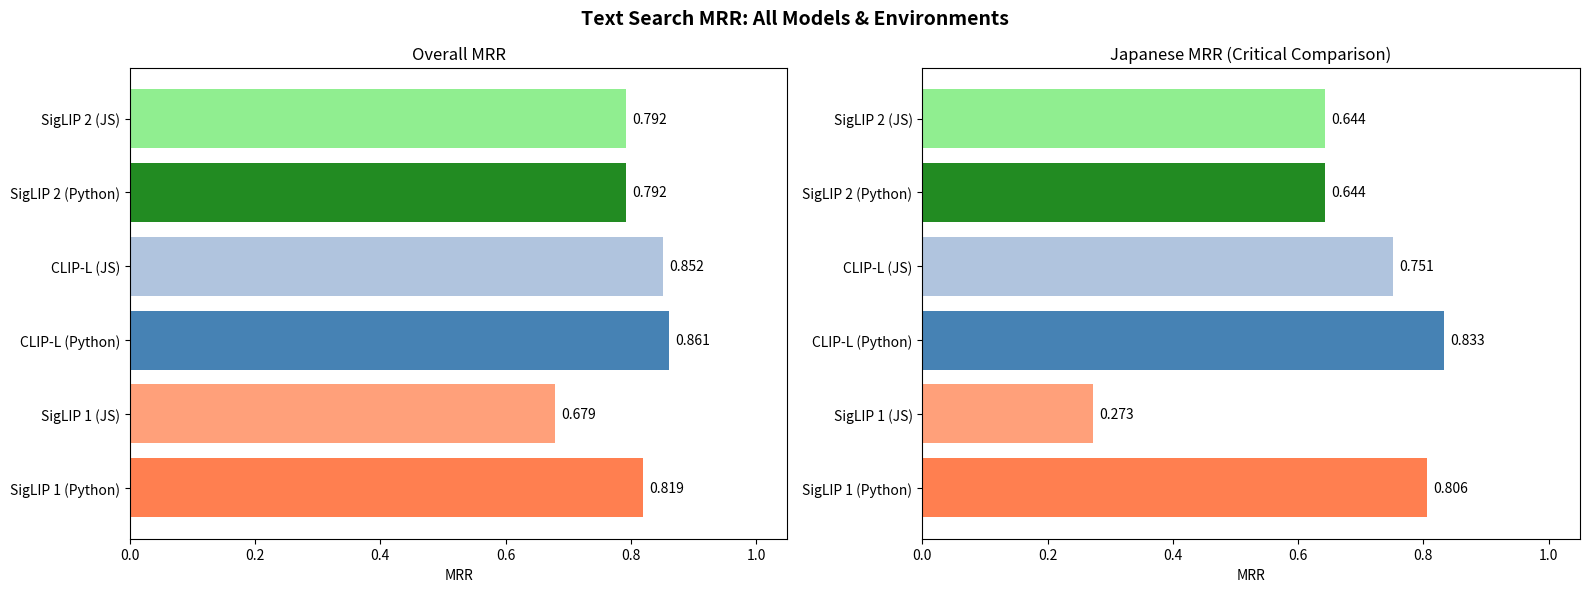

Saved: data/siglip2_js_japanese_comparison.png


In [14]:
# 可視化
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names = list(all_mrr.keys())
colors_map = {
    "SigLIP 1 (Python)": "coral",
    "SigLIP 1 (JS)": "lightsalmon",
    "CLIP-L (Python)": "steelblue",
    "CLIP-L (JS)": "lightsteelblue",
    "SigLIP 2 (Python)": "forestgreen",
    "SigLIP 2 (JS)": "lightgreen",
}

# 全体 MRR
ax = axes[0]
overall_mrrs = [all_mrr[m]['Overall'] for m in model_names]
bar_colors = [colors_map.get(m, 'gray') for m in model_names]
bars = ax.barh(model_names, overall_mrrs, color=bar_colors)
ax.set_xlabel('MRR')
ax.set_title('Overall MRR')
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, overall_mrrs):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', fontsize=10)

# 日本語 MRR（最重要）
ax = axes[1]
ja_mrrs = [all_mrr[m]['JA'] for m in model_names]
bars = ax.barh(model_names, ja_mrrs, color=bar_colors)
ax.set_xlabel('MRR')
ax.set_title('Japanese MRR (Critical Comparison)')
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, ja_mrrs):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', fontsize=10)

plt.suptitle('Text Search MRR: All Models & Environments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/siglip2_js_japanese_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/siglip2_js_japanese_comparison.png')

## 8. 結果の保存

In [15]:
output_data = {
    "timestamp": datetime.now().isoformat(),
    "tokenizer_comparison": comparison_data,
    "text_embedding_similarity": text_sims if js_text_output else [],
    "search_mrr": {k: v for k, v in all_mrr.items()},
    "conclusion": {
        "siglip2_js_japanese_unk": any(d['js_unk'] for d in comparison_data if d['lang'] == 'JA'),
        "siglip1_js_japanese_unk": True,
    },
}

output_path = Path("../data/evaluations") / f"siglip2_js_tokenizer_japanese_{datetime.now().strftime('%Y-%m-%d')}.json"
with open(output_path, "w") as f:
    json.dump(output_data, f, indent=2, default=str, ensure_ascii=False)

print(f"Results saved to: {output_path}")

Results saved to: ../data/evaluations/siglip2_js_tokenizer_japanese_2026-02-16.json


## 9. GPU メモリクリーンアップ

In [16]:
del embedder

import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU memory cleared.")

GPU memory cleared.


## まとめ・評価・考察

### 最重要実験結果: Gemma BPE トークナイザーで日本語問題は完全解決

SigLIP 2 の Gemma BPE トークナイザーにより、SigLIP 1 で壊滅的だった
**JS での日本語テキスト処理** が完全に解決された。

### 実験結果サマリー

#### 1. トークナイザー比較

| モデル | トークナイザー | JS 日本語 `<unk>` | Input IDs 一致 |
|--------|:---:|:---:|:---:|
| SigLIP 1 | Unigram (32K) | **あり（全滅）** | EN: 一致, JA: 不一致 |
| CLIP-L | BPE (49K) | なし | 一致 |
| **SigLIP 2** | **Gemma BPE (256K)** | **なし** | **全テキスト完全一致** |

- Python と JS のトークン列（input_ids）が英語・日本語ともに完全一致
- SigLIP 1 の Unigram トークナイザーの `byte_fallback` 未実装問題は、Gemma BPE への変更で根本的に解消

#### 2. テキスト埋め込みの Python-JS 一致度

| モデル | 英語 cos sim | 日本語 cos sim |
|--------|:---:|:---:|
| SigLIP 1 | 1.000 | 0.656 |
| CLIP-L | 1.000 | 1.000 |
| **SigLIP 2** | **1.000** | **1.000** |

- **SigLIP 2 は英語・日本語ともにコサイン類似度 1.000（完全一致！）**
- SigLIP 1 の日本語 0.656 から劇的に改善
- CLIP-L と同等の完全な Python-JS テキスト互換性を達成

#### 3. テキスト→画像検索 MRR

| モデル・環境 | EN MRR | JA MRR | Overall |
|:---|:---:|:---:|:---:|
| SigLIP 1 (Python) | 0.826 | 0.806 | 0.819 |
| SigLIP 1 (JS) | 0.883 | **0.273** | 0.679 |
| CLIP-L (Python) | 0.875 | 0.833 | 0.861 |
| CLIP-L (JS) | 0.903 | 0.751 | 0.852 |
| SigLIP 2 (Python) | 0.866 | 0.644 | 0.792 |
| **SigLIP 2 (JS)** | **0.866** | **0.644** | **0.792** |

- **SigLIP 2 は Python と JS で検索結果が完全に一致**（MRR が同一値）
- SigLIP 1 JS の JA MRR 0.273 → SigLIP 2 JS の JA MRR 0.644（**+0.371 改善**）
- ただし SigLIP 2 Base の JA MRR 自体が 0.644 と、SigLIP 1 Python (0.806) より低い

### 考察

1. **最大の成果: Python-JS のギャップが完全に解消された**
   - SigLIP 1 では Python と JS で MRR に大きな差があった（EN: 同等, JA: 0.806 vs 0.273）
   - SigLIP 2 では Python と JS の結果が完全に同一
   - **実用上の意味: Python でモデルを事前計算し、JS で検索しても品質が一切劣化しない**

2. **残る課題は SigLIP 2 Base モデル自体の日本語性能**
   - JA MRR 0.644 は SigLIP 1 (0.806) や CLIP-L (0.833) より低い
   - これは JS 実装の問題ではなく、Base モデルの限界
   - Notebook 63 の結果から、SigLIP 2 Large なら JA MRR 1.000 を達成できる
   - → **Large モデルの ONNX 版が提供されれば JS でも最高性能が期待できる**

3. **Transformers.js の技術的注意点**
   - `SiglipTextModel` を使用（`AutoModel` は不可）
   - `max_length: 64` を明示的に指定する必要がある（Gemma の `model_max_length` が巨大なため）
   - `pooler_output` から埋め込みを取得

4. **SigLIP 1 → SigLIP 2 への移行の推奨**
   - JS での日本語対応が根本的に改善されたため、SigLIP 2 への移行を推奨
   - 特に多言語テキスト検索を行うユースケースでは SigLIP 2 が明確に優位
   - Base モデルの日本語検索性能が気になる場合は CLIP-L を併用するか、Large モデルの ONNX 化を待つ